In [144]:
import gzip
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [145]:
subID='001'
sesID='001'
modality = "concentric"
torque_file_path = f"""\\Program Files\\DigiMove\\DigiMove\\DataAnalysisProject\\data\\MOXY-bids\\MOXY-bids\\sub-{subID}\\ses-{sesID}\\beh\\sub-{subID}_ses-{sesID}_task-{modality}_recording-angle_physio.tsv.gz"""

In [146]:
#Extract .gz file
with gzip.open(torque_file_path, 'rb') as f_in:
    with open('file', 'wb') as f_out:
       shutil.copyfileobj(f_in, f_out)

In [147]:
#load the tsv file that was extracted
df = pd.read_csv(torque_file_path, sep='\t', header=None, names=['torque_Nm'])
#display the first few rows of the dataframe to check if it loaded correctly
print(df.head())
print(df.columns)


   torque_Nm
0   0.280608
1   0.280931
2   0.281253
3   0.281897
4   0.280286
Index(['torque_Nm'], dtype='str')


In [148]:
events_filepath = f"""\\Program Files\\DigiMove\\DigiMove\\DataAnalysisProject\\data\\MOXY-bids\\MOXY-bids\\sub-{subID}\\ses-{sesID}\\beh\\sub-{subID}_ses-{sesID}_task-{modality}_events.tsv"""
events = pd.read_csv(events_filepath, sep="\t")
print(events)

duration=events["onset"].max()
fs=len(df)/duration
df["time"] = np.arange(len(df))/fs



          onset  duration      trial_type
0    105.661988         0  OcclusionStart
1    405.707634         0   OcclusionStop
2    921.633348         0             MVC
3    995.582740         0             MVC
4   1069.042123         0             MVC
5   1263.743788         0           Con50
6   1392.376209         0           Con50
7   1522.324655         0           Con50
8   1735.228663         0           Con30
9   1865.105107         0           Con30
10  1994.781548         0           Con30
11  2209.253585         0             MVC


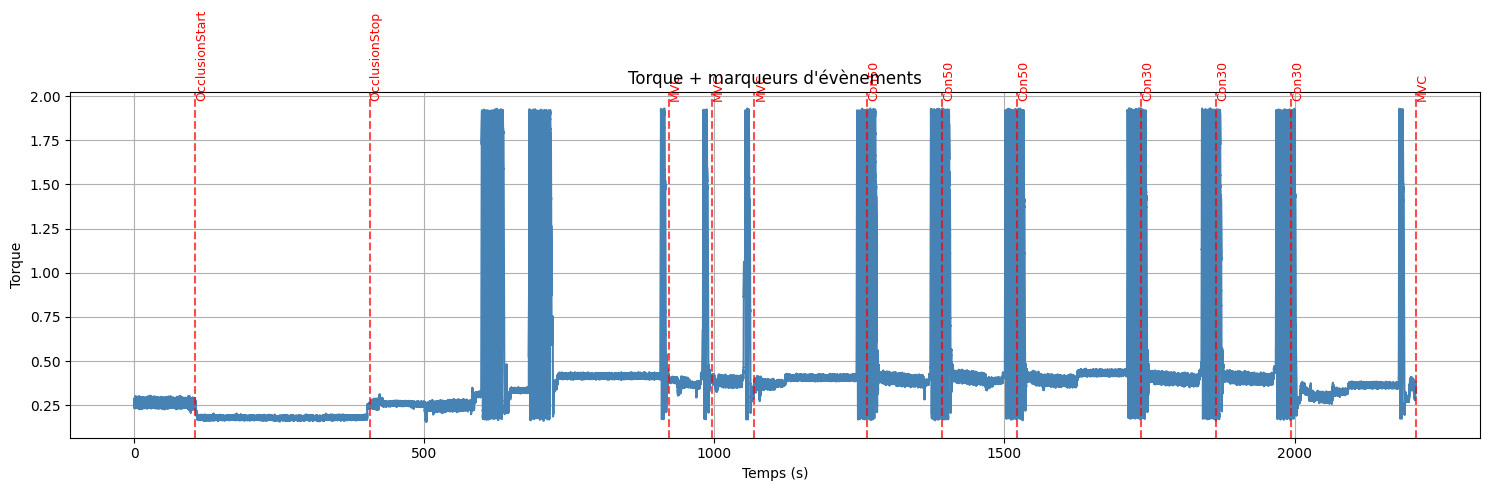

In [149]:
#visualize the data
plt.figure(figsize=(15, 5))

# Tracé du torque
plt.plot(df["time"], df["torque_Nm"], label="Torque", color="steelblue")

# Lignes verticales automatiques
for onset, label in zip(events["onset"], events["trial_type"]):
    plt.axvline(onset, color="red", linestyle="--", alpha=0.7)
    plt.text(onset, df["torque_Nm"].max()*1.02, label, rotation=90,
             verticalalignment="bottom", fontsize=9, color="red")

plt.xlabel("Temps (s)")
plt.ylabel("Torque")
plt.title("Torque + marqueurs d'évènements")
plt.grid(True)
plt.tight_layout()
plt.show()


Mean Torque: 0.446026131419636 Nm
Standard Deviation of Torque: 0.3635041132892504 Nm
Skewness of Torque: 2.818895719420479
Kurtosis of Torque: 7.349991631961421


c:\Users\dvxya\miniconda3\envs\valmoxy\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


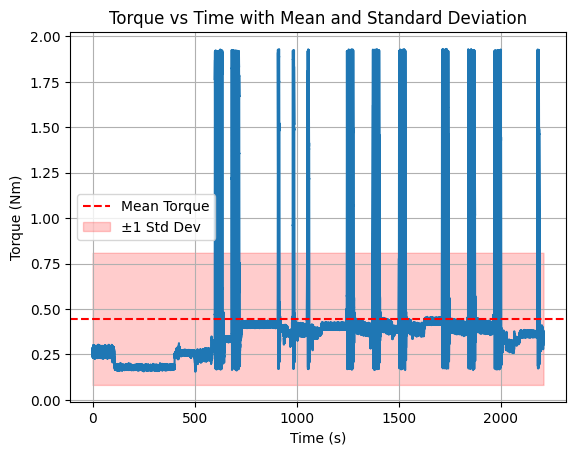

In [150]:
#extract the mean  
mean_torque = df['torque_Nm'].mean()
print(f'Mean Torque: {mean_torque} Nm')

#extract the strandard deviation
std_torque = df['torque_Nm'].std()
print(f'Standard Deviation of Torque: {std_torque} Nm')

#extract skewness
skewness_torque = df['torque_Nm'].skew()
print(f'Skewness of Torque: {skewness_torque}')

#extract kurtosis
kurtosis_torque = df['torque_Nm'].kurtosis()
print(f'Kurtosis of Torque: {kurtosis_torque}')

#and plot the linegraph 

plt.plot(df['time'], df['torque_Nm'])
plt.axhline(mean_torque, color='red', linestyle='--', label='Mean Torque')
plt.fill_between(df['time'], mean_torque - std_torque, mean_torque + std_torque, color='red', alpha=0.2, label='±1 Std Dev')
plt.xlabel('Time (s)')  
plt.ylabel('Torque (Nm)')
plt.title('Torque vs Time with Mean and Standard Deviation')
plt.legend()
plt.grid()
plt.show()



Phases détectées automatiquement :
Phase 1: 106.6 s → 401.6 s
Phase 2: 402.1 s → 409.6 s
Phase 3: 423.8 s → 500.8 s
Phase 4: 502.1 s → 503.8 s
Phase 5: 504.6 s → 507.4 s
Phase 6: 575.8 s → 577.6 s
Phase 7: 586.3 s → 588.0 s
Phase 8: 588.3 s → 598.1 s
Phase 9: 646.3 s → 648.4 s
Phase 10: 648.7 s → 680.0 s
Phase 11: 728.4 s → 729.9 s
Phase 12: 730.2 s → 906.8 s
Phase 13: 919.9 s → 935.5 s
Phase 14: 937.2 s → 939.2 s
Phase 15: 954.4 s → 968.4 s
Phase 16: 970.0 s → 974.6 s
Phase 17: 975.3 s → 976.8 s
Phase 18: 977.1 s → 979.9 s
Phase 19: 992.7 s → 996.6 s
Phase 20: 1001.4 s → 1005.5 s
Phase 21: 1048.0 s → 1049.6 s
Phase 22: 1051.4 s → 1052.9 s
Phase 23: 1064.8 s → 1067.6 s
Phase 24: 1100.9 s → 1102.0 s
Phase 25: 1102.0 s → 1122.1 s
Phase 26: 1122.4 s → 1244.9 s
Phase 27: 1285.2 s → 1288.1 s
Phase 28: 1363.1 s → 1369.7 s
Phase 29: 1370.1 s → 1372.1 s
Phase 30: 1467.8 s → 1469.9 s
Phase 31: 1477.1 s → 1497.1 s
Phase 32: 1497.4 s → 1500.6 s
Phase 33: 1538.8 s → 1543.9 s
Phase 34: 1543.9 s → 1

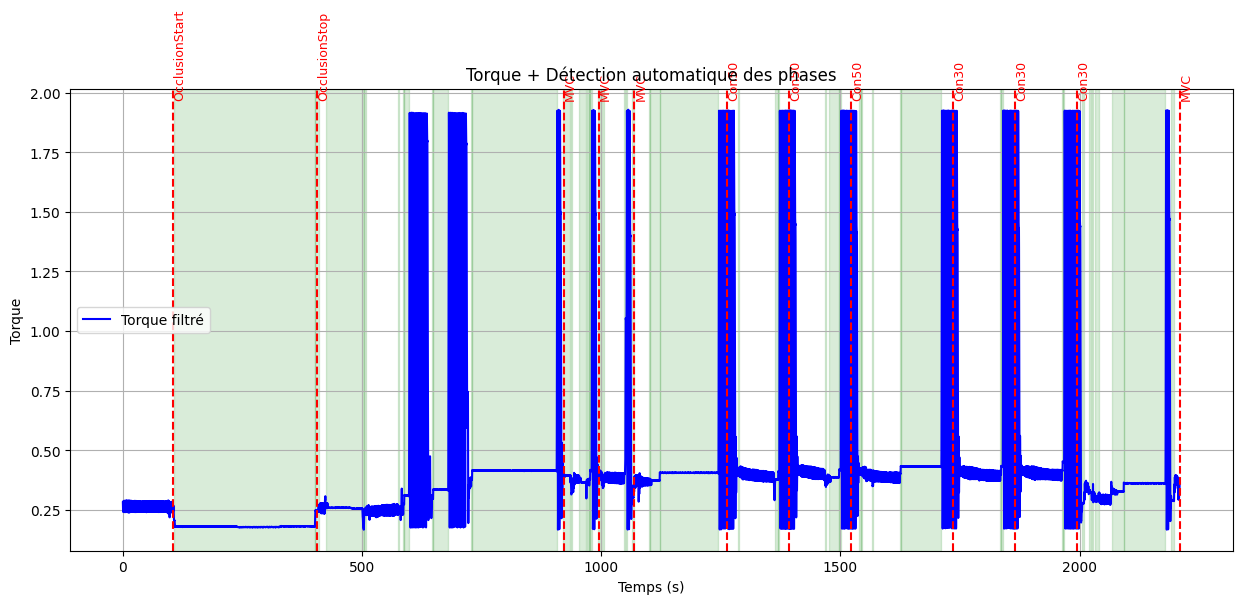

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# -------------------------------------------------------
# 1. Chargement automatique du torque
# -------------------------------------------------------
df = pd.read_csv(torque_file_path, sep="\t", header=None, names=["torque"])

# Reconstruction du temps
duration = events["onset"].max() if "events" in globals() else None
if duration is None:
    print("Pas d'events → estimation de la durée impossible automatiquement.")
    print("Veuillez fournir la durée totale du protocole.")
else:
    fs = len(df) / duration
    df["time"] = np.arange(len(df)) / fs

# -------------------------------------------------------
# 2. Filtrage léger (Savitzky-Golay)
# -------------------------------------------------------
df["torque_filt"] = savgol_filter(df["torque"], window_length=301, polyorder=3)

# -------------------------------------------------------
# 3. Détection automatique des transitions
# -------------------------------------------------------
# Dérivée du torque
df["dTorque"] = np.abs(np.gradient(df["torque_filt"], df["time"]))

# Zones stables = dérivée faible
med=np.median(df["dTorque"])
mad=np.median(np.abs(df["dTorque"] - med))
threshold = med+3*mad
df["stable"] = df["dTorque"] < threshold

# Groupement des zones stables
df["phase_id"] = (df["stable"] != df["stable"].shift()).cumsum()

phases = []
for pid, chunk in df.groupby("phase_id"):
    if chunk["stable"].iloc[0]:  # garder seulement zones stables
        start = chunk["time"].iloc[0]
        end = chunk["time"].iloc[-1]
        if end - start > 1.0:     # ignorer segments trop courts
            phases.append((start, end))

print("Phases détectées automatiquement :")
for i, (s, e) in enumerate(phases):
    print(f"Phase {i+1}: {s:.1f} s → {e:.1f} s")

# -------------------------------------------------------
# 4. Plot torque + events + phases détectées
# -------------------------------------------------------
plt.figure(figsize=(15, 6))

plt.plot(df["time"], df["torque_filt"], label="Torque filtré", color="blue")

# ------ si events.tsv existe, tracer les lignes ------
if "events" in globals():
    for onset, label in zip(events["onset"], events["trial_type"]):
        plt.axvline(onset, color="red", linestyle="--")
        plt.text(onset, df["torque_filt"].max()*1.02, label,
                 rotation=90, verticalalignment="bottom",
                 fontsize=9, color="red")

# ------ tracer les phases détectées automatiquement ------
for i, (s, e) in enumerate(phases):
    plt.axvspan(s, e, color="green", alpha=0.15)

plt.xlabel("Temps (s)")
plt.ylabel("Torque")
plt.title("Torque + Détection automatique des phases")
plt.grid(True)
plt.legend()
plt.show()

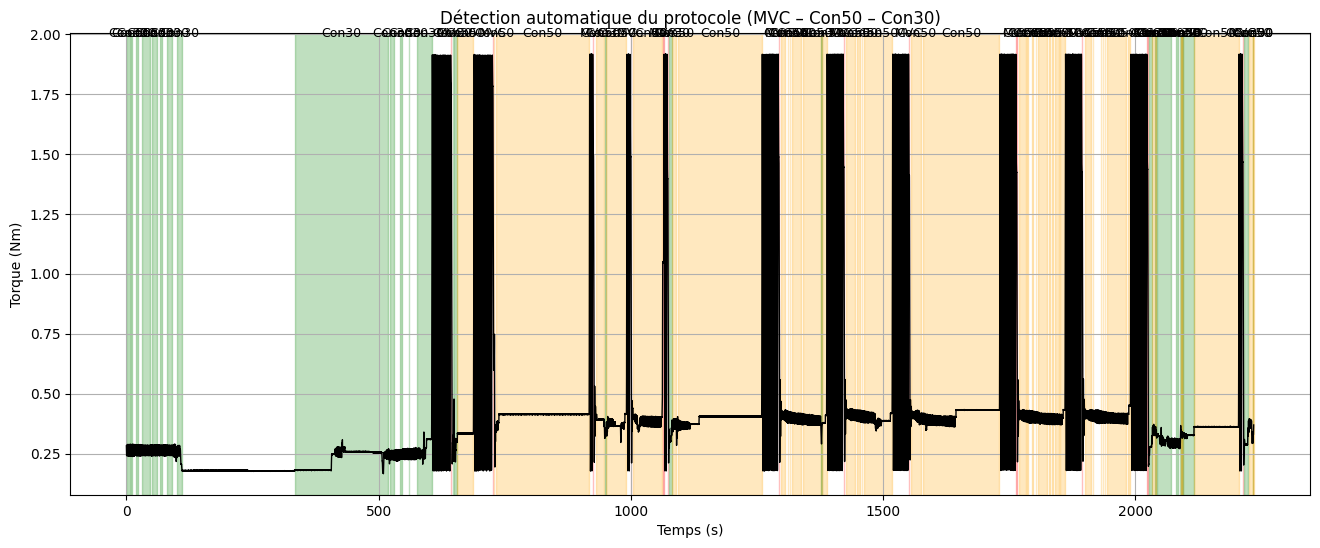

In [158]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.cluster import KMeans
import sklearn.cluster as _sk_cluster

# Compat patch so the existing line `from sklearn.cluster import KMeansdef` does not fail
if not hasattr(_sk_cluster, "KMeansdef"):
    _sk_cluster.KMeansdef = KMeans
from sklearn.cluster import KMeansdef

def load_torque(torque_path):
    df = pd.read_csv(torque_path, sep="\t", header=None, names=["torque"])
    df["torque"] = pd.to_numeric(df["torque"], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    return df

def compute_time(df, fs):
    df["time"] = np.arange(len(df)) / fs
    return df

def smooth_signal(x, fs):
    win = max(5, int(0.2 * fs) | 1)
    return savgol_filter(x, win, 3)

def detect_contractions(df, fs, min_dur=0.3):
    x = df["torque_filt"].to_numpy()
    t = df["time"].to_numpy()

    # dérivée réelle (utilise dt)
    d = np.abs(np.gradient(x, t))

    # seuil dérivée via MAD (robuste)
    med = np.median(d)
    mad = np.median(np.abs(d - med))
    thr = med + 3 * mad

    # amplitude (évite les zones proches de 0)
    amp_thr = np.percentile(np.abs(x), 10)

    stable = (d < thr) & (np.abs(x) > amp_thr)

    # segmentation
    phases = []
    in_phase = False
    start = None

    for i in range(len(stable)):
        if stable[i] and not in_phase:
            in_phase = True
            start = t[i]
        elif not stable[i] and in_phase:
            end = t[i]
            if end - start > min_dur:
                phases.append((start, end))
            in_phase = False

    return phases

def cluster_phases(phases, df):
    amps = []
    for (s, e) in phases:
        mask = (df["time"] >= s) & (df["time"] <= e)
        amps.append(np.abs(df.loc[mask, "torque_filt"]).mean())

    phase_df = pd.DataFrame(phases, columns=["start", "end"])
    phase_df["mean_amp"] = amps

    kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto")
    phase_df["cluster"] = kmeans.fit_predict(phase_df[["mean_amp"]])

    # ordonner les clusters du plus faible au plus fort
    order = phase_df.groupby("cluster")["mean_amp"].mean().sort_values().index.tolist()
    mapping = {
        order[0]: "Con30",
        order[1]: "Con50",
        order[2]: "MVC"
    }
    phase_df["label"] = phase_df["cluster"].map(mapping)

    return phase_df

def group_into_blocks(phase_df, max_gap=3.0):
    blocks = []
    current = [phase_df.iloc[0].start, phase_df.iloc[0].end, phase_df.iloc[0].label]

    for i in range(1, len(phase_df)):
        row = phase_df.iloc[i]
        gap = row.start - current[1]

        # si même label et proche dans le temps → même bloc
        if row.label == current[2] and gap < max_gap:
            current[1] = row.end
        else:
            blocks.append(tuple(current))
            current = [row.start, row.end, row.label]

    blocks.append(tuple(current))
    return blocks

def plot_blocks(df, blocks):
    plt.figure(figsize=(16,6))
    plt.plot(df["time"], df["torque_filt"], color="black", linewidth=1)

    colors = {"MVC":"red", "Con50":"orange", "Con30":"green"}

    ymax = df["torque_filt"].max()

    for (s, e, label) in blocks:
        plt.axvspan(s, e, color=colors[label], alpha=0.25)
        plt.text((s+e)/2, ymax*1.03, label, ha="center", va="bottom", fontsize=9)

    plt.xlabel("Temps (s)")
    plt.ylabel("Torque (Nm)")
    plt.title("Détection automatique du protocole (MVC – Con50 – Con30)")
    plt.grid(True)
    plt.show()

def analyze_protocol(torque_file_path, fs):
    df = load_torque(torque_file_path)
    df = compute_time(df, fs)
    df["torque_filt"] = smooth_signal(df["torque"], fs)

    phases = detect_contractions(df, fs)
    phase_df = cluster_phases(phases, df)
    blocks = group_into_blocks(phase_df)

    plot_blocks(df, blocks)

    return {
        "df": df,
        "phases": phase_df,
        "blocks": blocks
    }

results = analyze_protocol(torque_file_path, fs=500)